# Titanic — Data Preprocessing Exercises XP

Ce notebook suit une narration de prétraitement cohérente sur le dataset Titanic (`train.csv`) :

1. Détection et suppression des doublons  
2. Gestion des valeurs manquantes  
3. Feature engineering  
4. Détection et traitement des outliers  
5. Standardisation et normalisation  
6. Encodage final des variables catégorielles  
7. Transformation de l’âge en groupes

> Le but est pédagogique : comprendre les fonctions de prétraitement et les appliquer dans le bon ordre.


In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


## Chargement du dataset

Le notebook essaie plusieurs chemins possibles pour rester pratique si le fichier est nommé `train.csv` ou `train(1).csv`.


In [3]:
def load_titanic_dataset() -> pd.DataFrame:
    # On essaie plusieurs noms possibles pour rendre le notebook facilement réutilisable.
    candidates = [
        Path("train.csv"),
        Path("/mnt/data/train.csv"),
    ]
    for path in candidates:
        if path.exists():
            return pd.read_csv(path)
    raise FileNotFoundError(
        "Impossible de trouver le fichier Titanic. Placez train.csv ou train(1).csv dans le même dossier que le notebook."
    )

raw_df = load_titanic_dataset()
df = raw_df.copy()

print(f"Shape initiale : {df.shape}")
display(df.head())


Shape initiale : (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Exercice 1 — Détection et suppression des doublons

Ici, on vérifie si le dataset contient des lignes dupliquées sur **toutes** les colonnes, puis on les supprime si nécessaire.


In [4]:
duplicate_count = df.duplicated().sum()
print(f"Nombre de doublons détectés : {duplicate_count}")

rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
rows_after = len(df)

print(f"Nombre de lignes avant suppression : {rows_before}")
print(f"Nombre de lignes après suppression  : {rows_after}")
print(f"Doublons supprimés                  : {rows_before - rows_after}")


Nombre de doublons détectés : 0
Nombre de lignes avant suppression : 891
Nombre de lignes après suppression  : 891
Doublons supprimés                  : 0


## Exercice 2 — Gestion des valeurs manquantes

On applique trois stratégies différentes selon la nature de la colonne :

- **Suppression** : pour `Embarked`, car seulement 2 valeurs manquantes
- **Imputation médiane** : pour `Age`, robuste aux valeurs extrêmes
- **Valeur constante** : pour `Cabin`, car beaucoup de valeurs manquantes ; on conserve l'information manquante sous la forme `"Unknown"`

On conserve une logique simple et explicable pour un futur modèle.


In [5]:
# 1) Vue d'ensemble des valeurs manquantes
missing_counts = df.isna().sum().sort_values(ascending=False)
display(missing_counts[missing_counts > 0])

# 2) Suppression des lignes où Embarked est manquant (cas très rare)
df = df.dropna(subset=["Embarked"]).reset_index(drop=True)

# 3) Imputation médiane pour Age
age_imputer = SimpleImputer(strategy="median")
df[["Age"]] = age_imputer.fit_transform(df[["Age"]])

# 4) Remplissage constant pour Cabin
df["Cabin"] = df["Cabin"].fillna("Unknown")

print("Vérification après traitement des valeurs manquantes :")
display(df.isna().sum()[df.isna().sum() > 0])


Cabin       687
Age         177
Embarked      2
dtype: int64

Vérification après traitement des valeurs manquantes :


Series([], dtype: int64)

## Exercice 3 — Feature Engineering

On crée de nouvelles variables utiles :

- `FamilySize` = `SibSp + Parch + 1`
- `IsAlone` = indicateur binaire
- `Title` extrait depuis la colonne `Name`
- `CabinDeck` extrait depuis la première lettre de `Cabin`

On encode aussi `Title` avec un encodage simple par one-hot encoding, sans encore scaler les variables numériques.


In [6]:
def extract_title(name: str) -> str:
    match = re.search(r",\s*([^\.]+)\.", name)
    if match:
        title = match.group(1).strip()
    else:
        title = "Unknown"

    # Regroupement des titres rares pour réduire la cardinalité.
    title_map = {
        "Mlle": "Miss",
        "Ms": "Miss",
        "Mme": "Mrs",
        "Lady": "Rare",
        "Countess": "Rare",
        "Capt": "Rare",
        "Col": "Rare",
        "Don": "Rare",
        "Dr": "Rare",
        "Major": "Rare",
        "Rev": "Rare",
        "Sir": "Rare",
        "Jonkheer": "Rare",
        "Dona": "Rare",
    }
    title = title_map.get(title, title)

    # Tous les titres qui ne sont pas très fréquents sont regroupés dans "Rare".
    if title not in {"Mr", "Miss", "Mrs", "Master"}:
        title = "Rare"
    return title

def extract_cabin_deck(cabin) -> str:
    if pd.isna(cabin) or cabin == "Unknown":
        return "Unknown"
    return str(cabin)[0]

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["Title"] = df["Name"].apply(extract_title)
df["CabinDeck"] = df["Cabin"].apply(extract_cabin_deck)

# Encodage simple de Title à ce stade (comme demandé dans l'exercice 3)
title_dummies = pd.get_dummies(df["Title"], prefix="Title", dtype=int)
df = pd.concat([df, title_dummies], axis=1)

display(df[["Name", "Title", "FamilySize", "IsAlone", "Cabin", "CabinDeck"]].head())


,Name,Title,FamilySize,IsAlone,Cabin,CabinDeck
0,"Braund, Mr. Owen Harris",Mr,2,0,Unknown,Unknown
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,0,C85,C
2,"Heikkinen, Miss. Laina",Miss,1,1,Unknown,Unknown
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,0,C123,C
4,"Allen, Mr. William Henry",Mr,1,1,Unknown,Unknown


## Exercice 4 — Détection et traitement des outliers

On commence par visualiser `Age` et `Fare`.  
Ensuite, on utilise :

- la méthode **IQR** pour détecter les valeurs aberrantes ;
- un **capping quantile** pour `Fare` ;
- une **transformation logarithmique** pour limiter l'asymétrie de `Fare`;
- un **capping IQR** léger pour `Age`.

On compare aussi le nombre de points extrêmes avant/après.


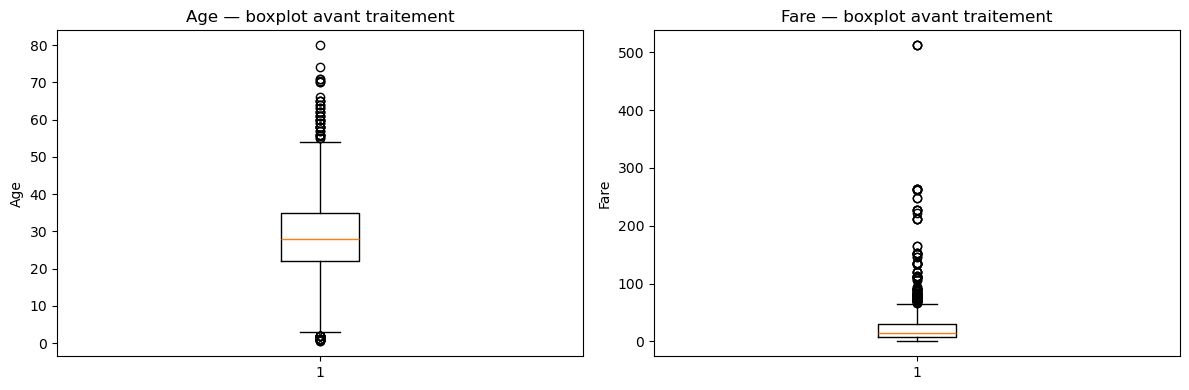

Age  : bornes IQR = [2.50, 54.50] | outliers détectés = 65
Fare : bornes IQR = [-26.76, 65.66] | outliers détectés = 114
Seuil de capping Fare (q=0.98) : 211.34


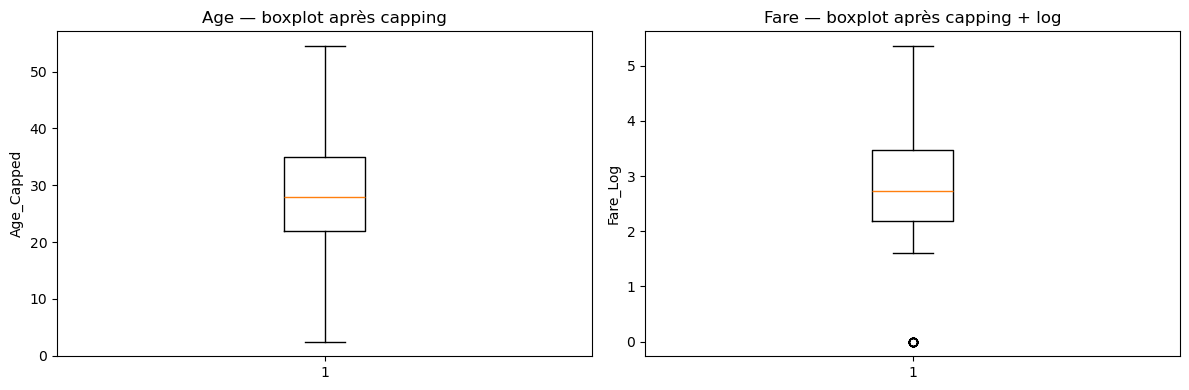

In [7]:
def iqr_bounds(series: pd.Series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper, q1, q3, iqr

# Visualisation rapide avant traitement
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df["Age"], vert=True)
axes[0].set_title("Age — boxplot avant traitement")
axes[0].set_ylabel("Age")

axes[1].boxplot(df["Fare"], vert=True)
axes[1].set_title("Fare — boxplot avant traitement")
axes[1].set_ylabel("Fare")
plt.tight_layout()
plt.show()

# Détection IQR
age_lb, age_ub, age_q1, age_q3, age_iqr = iqr_bounds(df["Age"])
fare_lb, fare_ub, fare_q1, fare_q3, fare_iqr = iqr_bounds(df["Fare"])

age_outliers = ((df["Age"] < age_lb) | (df["Age"] > age_ub)).sum()
fare_outliers = ((df["Fare"] < fare_lb) | (df["Fare"] > fare_ub)).sum()

print(f"Age  : bornes IQR = [{age_lb:.2f}, {age_ub:.2f}] | outliers détectés = {age_outliers}")
print(f"Fare : bornes IQR = [{fare_lb:.2f}, {fare_ub:.2f}] | outliers détectés = {fare_outliers}")

# Pour l'interprétation métier, on préfère souvent combiner :
# - capping quantile pour les grosses queues de distribution (Fare)
# - clipping IQR pour Age afin d'éviter quelques âges extrêmes
fare_cap = df["Fare"].quantile(0.98)  # seuil empirique justifié par le quantile élevé
df["Fare_Capped"] = df["Fare"].clip(upper=fare_cap)
df["Fare_Log"] = np.log1p(df["Fare_Capped"])

df["Age_Capped"] = df["Age"].clip(lower=max(0, age_lb), upper=age_ub)

print(f"Seuil de capping Fare (q=0.98) : {fare_cap:.2f}")

# Comparaison visuelle après traitement
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df["Age_Capped"], vert=True)
axes[0].set_title("Age — boxplot après capping")
axes[0].set_ylabel("Age_Capped")

axes[1].boxplot(df["Fare_Log"], vert=True)
axes[1].set_title("Fare — boxplot après capping + log")
axes[1].set_ylabel("Fare_Log")
plt.tight_layout()
plt.show()


In [8]:
# Démonstration optionnelle : combien de lignes seraient supprimées si on utilisait une stratégie de retrait de lignes ?
rows_before_outlier_removal = len(df)
mask_no_fare_outlier = (df["Fare"] >= fare_lb) & (df["Fare"] <= fare_ub)
df_removed_demo = df.loc[mask_no_fare_outlier].copy()
rows_after_outlier_removal = len(df_removed_demo)

print(f"Lignes avant retrait des outliers Fare : {rows_before_outlier_removal}")
print(f"Lignes après retrait des outliers Fare : {rows_after_outlier_removal}")
print(f"Nombre de lignes potentiellement supprimées : {rows_before_outlier_removal - rows_after_outlier_removal}")

# On conserve df avec les versions traitées (capping + log) pour la suite du notebook.


Lignes avant retrait des outliers Fare : 889
Lignes après retrait des outliers Fare : 775
Nombre de lignes potentiellement supprimées : 114


## Exercice 5 — Standardisation et normalisation

On applique les scalers après le traitement des outliers.

- **StandardScaler** pour les variables numériques de type presque continu : `Age_Capped`, `FamilySize`
- **MinMaxScaler** pour une variable asymétrique comme `Fare_Log`

L’idée est d’éviter que les valeurs extrêmes déforment les statistiques de mise à l’échelle.


In [9]:
# Préparation d'un sous-ensemble numérique propre
numeric_features = ["Age_Capped", "FamilySize", "Fare_Log"]

scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

df["Age_Std"] = scaler_standard.fit_transform(df[["Age_Capped"]])
df["FamilySize_Std"] = scaler_standard.fit_transform(df[["FamilySize"]])
df["Fare_MinMax"] = scaler_minmax.fit_transform(df[["Fare_Log"]])

display(df[["Age_Capped", "Age_Std", "FamilySize", "FamilySize_Std", "Fare_Log", "Fare_MinMax"]].head())


,Age_Capped,Age_Std,FamilySize,FamilySize_Std,Fare_Log,Fare_MinMax
0,22.0,-0.581209,2,0.057853,2.110213,0.393830
1,38.0,0.747162,2,0.057853,4.280593,0.798890
2,26.0,-0.249116,1,-0.561804,2.188856,0.408508
3,35.0,0.498092,2,0.057853,3.990834,0.744812
4,35.0,0.498092,1,-0.561804,2.202765,0.411103


## Exercice 6 — Encodage des variables catégorielles

On encode les catégories restantes :

- `Sex`
- `Embarked`
- `CabinDeck`

On utilise ici `OneHotEncoder` de scikit-learn pour produire des colonnes numériques prêtes pour un modèle.


In [10]:
categorical_cols = ["Sex", "Embarked", "CabinDeck"]

# On utilise OneHotEncoder avec gestion des catégories inconnues pour une meilleure robustesse.
# sparse_output=False rend le résultat directement manipulable comme un DataFrame.
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoded_array = encoder.fit_transform(df[categorical_cols])
encoded_cols = encoder.get_feature_names_out(categorical_cols)

encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=df.index)

# On construit une base finale avec les colonnes utiles :
# - identifiants et cible conservés
# - variables numériques traitées
# - variables catégorielles encodées
base_cols = [
    "PassengerId", "Survived", "Pclass", "SibSp", "Parch",
    "Age_Std", "FamilySize_Std", "Fare_MinMax"
]

# On garde aussi les variables intermédiaires utiles à la compréhension du travail réalisé.
intermediate_cols = ["Age_Capped", "Fare_Capped", "Fare_Log", "FamilySize", "IsAlone"] + list(df.columns[df.columns.str.startswith("Title_")])

final_df = pd.concat(
    [df[base_cols + intermediate_cols].reset_index(drop=True),
     encoded_df.reset_index(drop=True)],
    axis=1
)

display(final_df.head())
print(f"Shape finale du dataset préparé : {final_df.shape}")


,PassengerId,Survived,Pclass,SibSp,Parch,Age_Std,FamilySize_Std,Fare_MinMax,Age_Capped,Fare_Capped,Fare_Log,FamilySize,IsAlone,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,CabinDeck_A,CabinDeck_B,CabinDeck_C,CabinDeck_D,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T,CabinDeck_Unknown
0,1,0,3,1,0,-0.581209,0.057853,0.393830,22.0,7.2500,2.110213,2,0,0,0,1,0,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2,1,1,1,0,0.747162,0.057853,0.798890,38.0,71.2833,4.280593,2,0,0,0,0,1,0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,1,3,0,0,-0.249116,-0.561804,0.408508,26.0,7.9250,2.188856,1,1,0,1,0,0,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4,1,1,1,0,0.498092,0.057853,0.744812,35.0,53.1000,3.990834,2,0,0,0,0,1,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,0,3,0,0,0.498092,-0.561804,0.411103,35.0,8.0500,2.202765,1,1,0,0,1,0,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Shape finale du dataset préparé : (889, 32)


## Exercice 7 — Transformation de l’âge en groupes

On découpe `Age` en catégories de vie, puis on applique un one-hot encoding avec `pd.get_dummies()`.

Exemple de classes :

- child : 0–12 ans
- teen : 13–18 ans
- adult : 19–60 ans
- senior : 61 ans et plus


In [11]:
age_bins = [0, 12, 18, 60, 100]
age_labels = ["child", "teen", "adult", "senior"]

df["AgeGroup"] = pd.cut(df["Age"], bins=age_bins, labels=age_labels, include_lowest=True, right=True)
age_group_dummies = pd.get_dummies(df["AgeGroup"], prefix="AgeGroup", dtype=int)

display(df[["Age", "AgeGroup"]].head())
display(age_group_dummies.head())


,Age,AgeGroup
0,22.0,adult
1,38.0,adult
2,26.0,adult
3,35.0,adult
4,35.0,adult


,AgeGroup_child,AgeGroup_teen,AgeGroup_adult,AgeGroup_senior
0,0,0,1,0
1,0,0,1,0
2,0,0,1,0
3,0,0,1,0
4,0,0,1,0


## Conclusion

Le dataset Titanic a été prétraité dans un ordre logique :

1. doublons  
2. valeurs manquantes  
3. feature engineering  
4. outliers  
5. standardisation / normalisation  
6. encodage  
7. transformation de l’âge

Le résultat final `final_df` est une base prête pour l’étape de modélisation.
